In [ ]:
import os

origin_data_root = "/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data"
os.listdir(origin_data_root)
dataset_dirs = [os.path.join(origin_data_root, dirname, 'data') for dirname in os.listdir(origin_data_root) if dirname.endswith('_data')]
dataset_dirs

['/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/114_data/data',
 '/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/118_data/data',
 '/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/092_data/data',
 '/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/282_data/data',
 '/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/030_data/data',
 '/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/028_data/data',
 '/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/045_data/data',
 '/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/117_data/data',
 '/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/999_data/data',
 '/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/034_data/data']

In [18]:
[os.path.exists(dataset_dirs[i]) for i in range(len(dataset_dirs))]

[True, True, True, True, True, True, True, True, True, True]

In [19]:
dataset_dicts = {
    key.split('/')[-2]: [os.path.join(key, filename) for filename in os.listdir(key) if not filename.endswith('.json') or filename.endswith('.csv')]
    for key in dataset_dirs
}

In [20]:
dataset_dicts.keys()

dict_keys(['114_data', '118_data', '092_data', '282_data', '030_data', '028_data', '045_data', '117_data', '999_data', '034_data'])

In [21]:
for key, val in dataset_dicts.items():
    print(f"{key}: {len(val)} images")

114_data: 61037 images
118_data: 2484 images
092_data: 66636 images
282_data: 23921 images
030_data: 1624 images
028_data: 12545 images
045_data: 9005 images
117_data: 16761 images
999_data: 5826 images
034_data: 5400 images


In [ ]:
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import numpy as np
import cv2
import os

def compute_v_hist(image_path: str) -> np.ndarray:
    '''
    이미지에서 hsv 공간의 v 채널 히스토그램 계산 -> 256 크기의 배열 반환 == 0~255 픽셀 값에 대한 빈도 수
    '''
    try:
        img = cv2.imread(image_path, cv2.IMREAD_COLOR)

        img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        v = img_hsv[:, :, 2].ravel()
        # bincount가 더 빠르고 picklable
        hist = np.bincount(v, minlength=256)
        return hist.astype(np.int64, copy=False)
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return np.zeros(256, dtype=np.int64)

for dataset, image_paths in dataset_dicts.items():
    save_dir = os.path.dirname(os.path.dirname(image_paths[0]))

    if os.path.exists(os.path.join(save_dir, "hsv_v_values.npy")):
        print(f"{dataset}: already exists, skipping...")
        continue
    if not image_paths:
        continue

    total_hist = np.zeros(256, dtype=np.int64)
    n_workers = max(1, (os.cpu_count() or 2) - 1)

    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        for h in tqdm(ex.map(compute_v_hist, image_paths),
                      total=len(image_paths),
                      desc=f"{dataset}"):
            if h.sum() > 0:
                total_hist += h

    out_path = os.path.join(save_dir, "hsv_v_values.npy")
    np.save(out_path, total_hist)
    print(f"{dataset}: saved -> {out_path}")

114_data: already exists, skipping...
118_data: already exists, skipping...
092_data: already exists, skipping...
282_data: already exists, skipping...
030_data: already exists, skipping...
028_data: already exists, skipping...


045_data:  14%|█▍        | 1305/9005 [00:18<02:08, 59.92it/s]

Error processing /home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/045_data/data/F0083_IND_F_45_ 0_05.JPG: OpenCV(4.11.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'
Error processing /home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/045_data/data/F0083_IND_F_45_ 0_01.JPG: OpenCV(4.11.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'
Error processing /home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/045_data/data/F0083_IND_F_45_ 0_02.JPG: OpenCV(4.11.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'





[ WARN:0@3237.502] global loadsave.cpp:268 findDecoder imread_('/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/045_data/data/F0083_IND_F_45_ 0_01.JPG'): can't open/read file: check file path/integrity
[ WARN:0@3237.503] global loadsave.cpp:268 findDecoder imread_('/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/045_data/data/F0083_IND_F_45_ 0_02.JPG'): can't open/read file: check file path/integrity
[ WARN:0@3237.503] global loadsave.cpp:268 findDecoder imread_('/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/045_data/data/F0083_IND_F_45_ 0_05.JPG'): can't open/read file: check file path/integrity
045_data:  65%|██████▍   | 5845/9005 [01:29<01:00, 52.36it/s] 

Error processing /home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/045_data/data/F0083_IND_F_45_ 0_03.JPG: OpenCV(4.11.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'

Error processing /home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/045_data/data/F0083_IND_F_45_ 0_04.JPG: OpenCV(4.11.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'



...

117_data: saved -> /home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/117_data/hsv_v_values.npy


999_data:  66%|██████▌   | 3824/5826 [02:29<00:41, 48.78it/s]Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
999_data:  66%|██████▌   | 3842/5826 [02:29<00:37, 53.56it/s]Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
999_data:  69%|██████▉   | 4022/5826 [02:33<00:38, 46.48it/s]Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
999_data:  69%|██████▉   | 4027/5826 [02:33<00:42, 42.64it/s]Invalid SOS parameters for sequential JPEG
Invalid SOS parameters fo

999_data: saved -> /home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/999_data/hsv_v_values.npy



034_data: 100%|██████████| 5400/5400 [02:40<00:00, 33.74it/s]


034_data: saved -> /home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/034_data/hsv_v_values.npy


In [2]:
def get_equalized_value(image_rgb, cdf):
    img_hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    v_channel = img_hsv[:, :, 2]
    equalized_value = (255*cdf[v_channel]).astype(np.uint8)
    img_hsv[:, :, 2] = equalized_value
    equalized_image = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)
    return equalized_image

In [3]:
import numpy as np
import re
import os

origin_data_root = "/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data"
dataset_dirs = sorted([os.path.join(origin_data_root, dirname) for dirname in os.listdir(origin_data_root) if dirname.endswith('_data')])
print([os.path.basename(path) for path in dataset_dirs])

def make_cdf_from_hsv_v_values(dataset_dirs: list, target_dirs: list=[]) -> tuple:
    global_values = np.zeros((256,), dtype=np.int64)

    for path in dataset_dirs:
        if re.search(r"[0-9]+_data$", path).group().replace('_data', '') in target_dirs or len(target_dirs) == 0:
            value_path = os.path.join(path, 'hsv_v_values.npy')
            v_values = np.load(value_path)
            global_values += v_values
            print(f"{path}: {v_values.sum()}")
    

    pdf = global_values / global_values.sum() # 각 픽셀 값의 비율
    cdf = np.cumsum(pdf)
    return cdf

['028_data', '030_data', '034_data', '045_data', '092_data', '114_data', '117_data', '118_data', '282_data', '999_data']


/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/028_data: 88318947660
/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/030_data: 25984000000
/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/034_data: 65842315776
/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/045_data: 56155323794
/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/092_data: 484234537511
/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/114_data: 506265292800
/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/117_data: 74288924871
/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/118_data: 12628755590
/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/282_data: 25082986496
/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/999_data: 71006207960


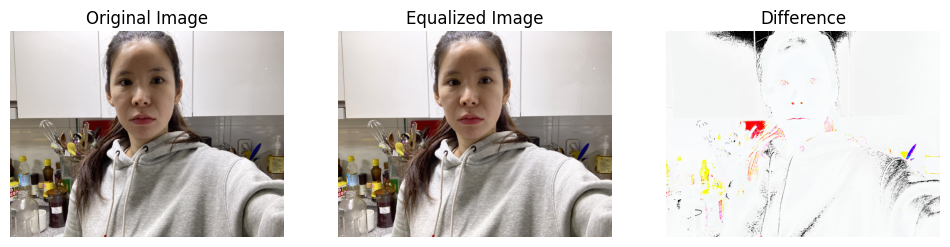

In [13]:
import matplotlib.pyplot as plt
import cv2

cdf = make_cdf_from_hsv_v_values(dataset_dirs)
img_path = '/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/092_data/data/0bd9e528462923082a9a0e921ebd06604429dc3211247552bdff25f0f3cae63a_여_30_중립_숙박 및 거주공간_20201207003601-010-004.jpg'
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
equalized_img = get_equalized_value(img_rgb, cdf)

fig, ax = plt.subplots(1, 3, figsize=(12, 6))
ax[0].imshow(img_rgb)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(equalized_img)
ax[1].set_title('Equalized Image')
ax[1].axis('off')

ax[2].imshow(img_rgb - equalized_img)
ax[2].set_title('Difference')
ax[2].axis('off')

plt.show()

In [15]:
with open('/home/work/hocheol_dir/workspace/_dataset/preprocess/exp.csv', 'rb') as f:
    print('hi')
    print(f.read())

hi
b'image_path,predicted_class\r\n/home/work/hocheol_dir/workspace/data/0000_CRS_19_01.jpg,1\r\n'


In [22]:
img_r.ravel()

array([225, 226, 229, ...,  63,  53,  56], dtype=uint8)

In [33]:
import numpy as np
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
hist = np.bincount(img_gray.ravel(), minlength=256)

In [34]:
pdf = hist / hist.sum()
cdf = np.cumsum(pdf)

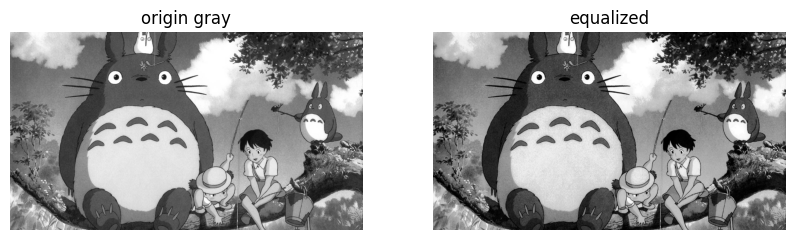

In [36]:
equalized_v = (255*cdf[img_gray]).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for i in range(2):
    ax[i].imshow([img_gray, equalized_v][i], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(['origin gray', 'equalized'][i])

plt.show()

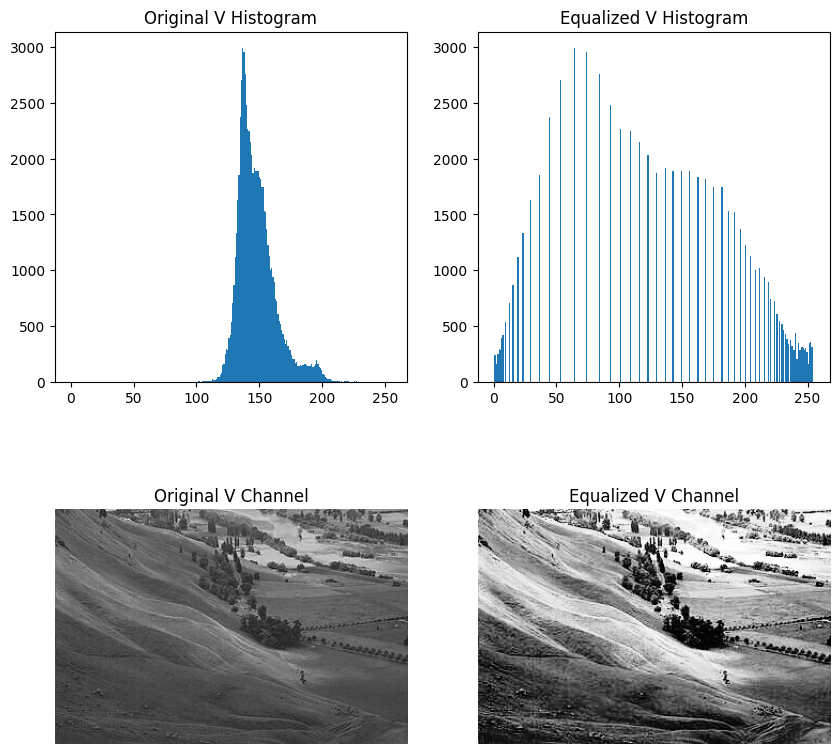

In [27]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_path = '/home/work/hocheol_dir/workspace/tmp/Unequalized_Hawkes_Bay_NZ.jpg'
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
v_value = img_hsv[:, :, 2]

pdf = np.bincount(v_value.ravel(), minlength=256)

# pdf2 = [0]*256
# for val in v_value.ravel():
#     pdf2[val] += 1
# pdf == np.array(pdf2)

cdf = np.cumsum(pdf / pdf.sum())
equalized_v = (255*cdf[v_value]).astype(np.uint8)

equalized_img_hsv = img_hsv.copy()
equalized_img_hsv[:, :, 2] = equalized_v
equalized_img = cv2.cvtColor(equalized_img_hsv, cv2.COLOR_HSV2RGB)

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
for i in range(2):
    ax[0][i].hist([v_value.ravel(), equalized_v.ravel()][i], bins=256, range=(0, 255))
    ax[0][i].set_title(['Original V Histogram', 'Equalized V Histogram'][i])

for i in range(2):
    ax[1][i].imshow([v_value, equalized_v][i], cmap='gray')
    ax[1][i].axis('off')
    ax[1][i].set_title(['Original V Channel', 'Equalized V Channel'][i])
plt.show()